In [2]:
## Main libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import shutil
import string
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn import model_selection, preprocessing, metrics

## Basic Classification libs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

## Preprocessing
import random
from nltk.corpus import wordnet
from transformers import BertTokenizer

import spacy
from spacy.lang.en.examples import sentences

import re
import nltk
from nltk.corpus import stopwords

## NN Model training
from tensorflow.keras import layers
from tensorflow.keras import losses

from tf_keras import Input, Model, layers
from transformers import TFBertModel, AutoConfig
from tf_keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [9]:
## LOAD DATA

train_data=pd.read_csv("/content/sample_data/train.csv")
test_data=pd.read_csv("/content/sample_data/test.csv")


train = (train_data["Title"] + " " + train_data["Description"]).astype(str)
test = (test_data["Title"] + " " + test_data["Description"]).astype(str)


In [4]:
## SETTINGS

batch_size = 32
seed = 42
max_features = 10000
sequence_length = 250
embedding_dim = 16


In [5]:
## TEXT PROCESSING UTILITIS

nltk.download('wordnet')

def synonym_replacement(sentence, n=2):
    words = sentence.split()
    new_words = words.copy()
    random_word_list = list(set([word for word in words if wordnet.synsets(word)]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if not synonyms:
            continue
        synonym_words = set()
        for syn in synonyms:
            for lemma in syn.lemmas():
                synonym_words.add(lemma.name())
        synonym_words.discard(random_word)
        if len(synonym_words) >= 1:
            synonym = random.choice(list(synonym_words))
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return " ".join(new_words)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def bert_tokenize(texts, max_length=128):
    return tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='tf'
    )

nlp = spacy.load("en_core_web_sm")

def lemmatize_text(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc])


nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)


def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '', ' ')
  return tf.strings.regex_replace(stripped_html,
                                  '[%s]' % re.escape(string.punctuation),
                                  '')

def preprocess_text(text):
  text = clean_text(text)
  text = lemmatize_text(text)
  text = synonym_replacement(text, n=2)
  return text

def tokenize_for_bert(texts, labels, max_length=128):
    tokenized = bert_tokenize(texts, max_length=max_length)
    return tokenized, labels

def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
## STEP 1

## Prepare data
X = pd.concat([train, test], ignore_index=True)
y = pd.concat([train_data["Class Index"], test_data["Class Index"]], ignore_index=True)

train_x, test_x, train_y, test_y =  model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(train_x.shape, test_x.shape)

## CountVectorizer
count_vect = CountVectorizer(stop_words='english')

count_vect.fit(train_x)

train_x_count = count_vect.transform(train_x)
test_x_count = count_vect.transform(test_x)
print(count_vect.get_feature_names_out())
print(train_x_count.toarray())
print(test_x_count.toarray())

## KNeighborsClassifier
KNN = KNeighborsClassifier()
KNN.fit(train_x_count, train_y)
predictions = KNN.predict(test_x_count)
print("\n=== KNN CountVectorizer ===")
print(metrics.classification_report(test_y, predictions))

## MultinomialNB
classifier = MultinomialNB()
classifier.fit(train_x_count, train_y)
predictions = classifier.predict(test_x_count)
print("\n=== MultinomialNB ===")
print(metrics.classification_report(test_y, predictions))

## LinearSVC
svm_model = LinearSVC()
svm_model.fit(train_x_count, train_y)
predictions = svm_model.predict(test_x_count)
print("\n=== SVM ===")
print(metrics.classification_report(test_y, predictions))

(102080,) (25520,)
['00' '000' '00010563n' ... 'zz' 'zzz' 'zzzzzz']
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

=== KNN CountVectorizer ===
              precision    recall  f1-score   support

           1       0.94      0.57      0.71      6380
           2       0.44      0.98      0.60      6380
           3       0.87      0.57      0.69      6380
           4       0.89      0.45      0.60      6380

    accuracy                           0.64     25520
   macro avg       0.78      0.64      0.65     25520
weighted avg       0.78      0.64      0.65     25520


=== MultinomialNB ===
              precision    recall  f1-score   support

           1       0.92      0.90      0.91      6380
           2       0.95      0.98      0.97      6380
           3       0.89      0.87      0.8

In [6]:
## STEP 2

### Prepare data

X = pd.concat([train, test], ignore_index=True)
y = pd.concat([train_data["Class Index"], test_data["Class Index"]], ignore_index=True)

train_x, test_x, train_y, test_y =  model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(train_x.shape, test_x.shape)

## TD-IDF Vectorization
tfidf_vect = TfidfVectorizer()
tfidf_vect.fit(train_x)

train_x_tfidf =  tfidf_vect.transform(train_x)
test_x_tfidf =  tfidf_vect.transform(test_x)

print(tfidf_vect.get_feature_names_out())
print(train_x_tfidf.toarray())
print(test_x_tfidf.toarray())

## KNeighborsClassifier
KNN = KNeighborsClassifier()
KNN.fit(train_x_tfidf, train_y)
predictions = KNN.predict(test_x_tfidf)
print("\n=== KNN CountVectorizer ===")
print(metrics.classification_report(test_y, predictions))


## Naive Bayes
classifier = MultinomialNB()
classifier.fit(train_x_tfidf, train_y)
predictions = classifier.predict(test_x_tfidf)
print("\n=== MultinomialNB ===")
print(metrics.classification_report(test_y, predictions))


## SVC
svm_model = LinearSVC()
svm_model.fit(train_x_tfidf, train_y)
predictions = svm_model.predict(test_x_tfidf)
print("\n=== SVM ===")
print(metrics.classification_report(test_y, predictions))

(102080,) (25520,)
['00' '000' '00010563n' ... 'zz' 'zzz' 'zzzzzz']
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

=== KNN CountVectorizer ===
              precision    recall  f1-score   support

           1       0.91      0.90      0.90      6380
           2       0.94      0.97      0.95      6380
           3       0.87      0.88      0.88      6380
           4       0.90      0.86      0.88      6380

    accuracy                           0.90     25520
   macro avg       0.90      0.90      0.90     25520
weighted avg       0.90      0.90      0.90     25520


=== MultinomialNB ===
              precision    recall  f1-score   support

           1       0.92      0.89      0.91      6380
           2       0.95 

         Unnamed: 0   Class Index
count  12000.000000  12000.000000
mean    6013.239333      2.500000
std     3488.139367      1.118081
min        0.000000      1.000000
25%     2999.750000      1.750000
50%     5999.500000      2.500000
75%     8999.250000      3.250000
max    12780.000000      4.000000
text_batch shape: (32,)
label_batch shape: (32,)
text_batch: tf.Tensor(
[b' #39;Jackal aide #39; in case 2 acquittal BERLIN, Germany -- A German court has acquitted Johannes Weinrich, said to be the right-hand man of international guerrilla  quot;Carlos the Jackal, quot; of charges that he took part in a deadly series of bombings in France in the early 1980s.'
 b'Costco faces sex discrimination suit An assistant manager at one of Costco #39;s Colorado warehouses filed a sex discrimination lawsuit against the Issaquah-based company yesterday, alleging that it overlooks women for promotion. '
 b'One dead, six missing after Maoist attack More than 1000 Maoist rebels stormed a district hea

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 246, 128)       │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,500 (673.83 KB)

 Trainable params: 172,500 (673.83 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.2661 - loss: 1.3794 - val_accuracy: 0.3713 - val_loss: 1.2898
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.4478 - loss: 1.2153 - val_accuracy: 0.4675 - val_loss: 1.1851
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.4904 - loss: 1.1517 - val_accuracy: 0.4779 - val_loss: 1.1819
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.5045 - loss: 1.1350 - val_accuracy: 0.4837 - val_loss: 1.1685
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.5064 - loss: 1.1236 - val_accuracy: 0.4950 - val_loss: 1.1541
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5126 - loss: 1.1130 - val_accuracy: 0.5008 - val_loss: 1.1423
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5165 - loss: 1.1027 - val_accuracy: 0.5075 - val_loss: 1.1299
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.5201 - loss: 1.0914 - val_ac

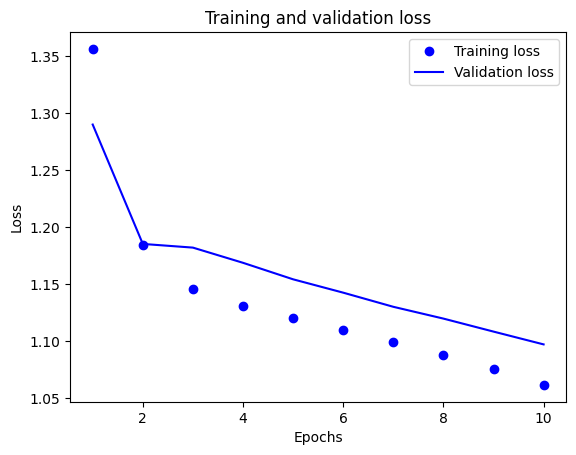

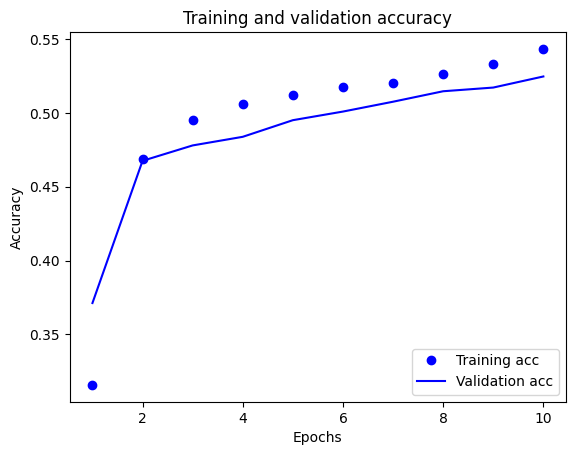

In [16]:
## STEP 3

### Prepare data

batch_size = 32
seed = 42
max_features = 10000
sequence_length = 250

train_data = pd.read_csv("/content/sample_data/train_subset.csv")
test_data = pd.read_csv("/content/sample_data/test.csv")

train_data["text"] = (train_data["Title"] + " " + train_data["Description"]).astype(str)
test_data["text"] = (test_data["Title"] + " " + test_data["Description"]).astype(str)

print(train_data.describe())

train_data = train_data.sample(frac=1, random_state=seed)

train_size = int(0.8 * len(train_data))
val_data = train_data[train_size:]
train_data = train_data[:train_size]

train_data["Class Index"] -= 1
val_data["Class Index"] -= 1
test_data["Class Index"] -= 1

raw_train_ds = tf.data.Dataset.from_tensor_slices((train_data["text"].values, train_data["Class Index"].values))
raw_val_ds = tf.data.Dataset.from_tensor_slices((val_data["text"].values, val_data["Class Index"].values))
raw_test_ds = tf.data.Dataset.from_tensor_slices((test_data["text"].values, test_data["Class Index"].values))

raw_train_ds = raw_train_ds.batch(batch_size)
raw_val_ds = raw_val_ds.batch(batch_size)
raw_test_ds = raw_test_ds.batch(batch_size)


for text_batch, label_batch in raw_train_ds.take(1):
    print("text_batch shape:", text_batch.shape)  # (32,)
    print("label_batch shape:", label_batch.shape)
    print("text_batch:", text_batch)

vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

train_text = raw_train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = raw_train_ds.shuffle(10000).map(vectorize_text).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = raw_val_ds.map(vectorize_text).cache().prefetch(buffer_size=AUTOTUNE)
test_ds = raw_test_ds.map(vectorize_text).cache().prefetch(buffer_size=AUTOTUNE)

embedding_dim = 16

model = tf.keras.Sequential([
    tf.keras.Input(shape=(sequence_length,), dtype=tf.int32),
    layers.Embedding(max_features, embedding_dim),
    layers.Conv1D(filters=128, kernel_size=5, activation='relu'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dense(4, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs)

loss, accuracy = model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

history_dict = history.history
history_dict.keys()

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 250, 50)        │         1,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 246, 128)       │        32,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,160 (141.25 KB)

 Trainable params: 36,160 (141.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - accuracy: 0.3097 - loss: 1.3720 - val_accuracy: 0.3921 - val_loss: 1.2207
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.4779 - loss: 1.1751 - val_accuracy: 0.5129 - val_loss: 1.1042
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.5380 - loss: 1.0878 - val_accuracy: 0.5633 - val_loss: 1.0267
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.5780 - loss: 1.0117 - val_accuracy: 0.6083 - val_loss: 0.9482
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.6158 - loss: 0.9396 - val_accuracy: 0.6371 - val_loss: 0.8954
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.6463 - loss: 0.8811 - val_accuracy: 0.6675 - val_loss: 0.8585
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.6710 - loss: 0.8334 - val_accuracy: 0.6783 - val_loss: 0.8245
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.6901 - loss: 0.7926 - 

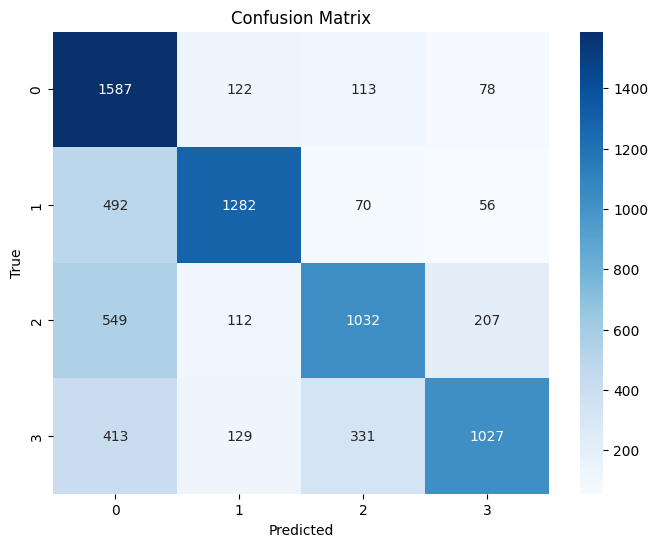

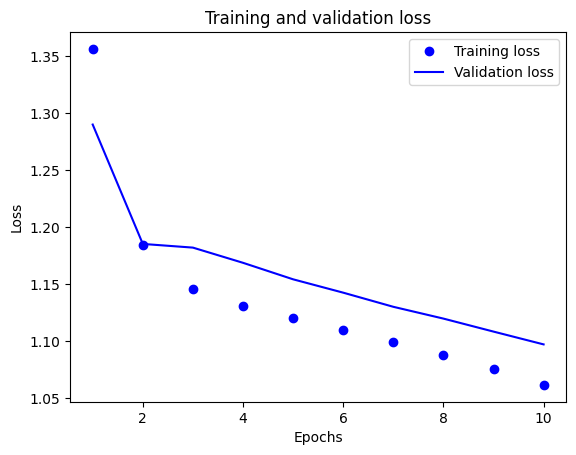

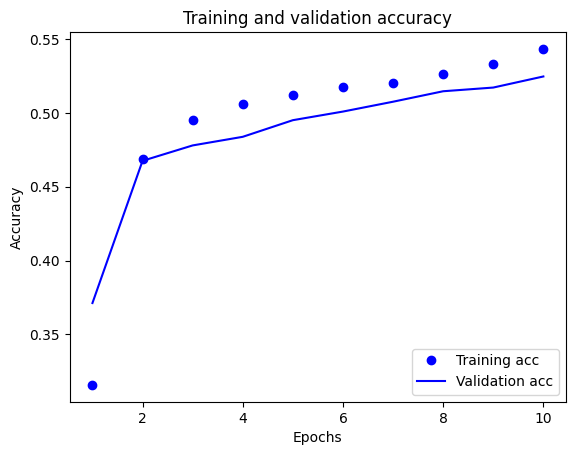

In [22]:
## STEP 4

### Prepare data

raw_train_ds = tf.data.Dataset.from_tensor_slices((train_data["text"].values, train_data["Class Index"].values))
raw_val_ds = tf.data.Dataset.from_tensor_slices((val_data["text"].values, val_data["Class Index"].values))
raw_test_ds = tf.data.Dataset.from_tensor_slices((test_data["text"].values, test_data["Class Index"].values))

raw_train_ds = raw_train_ds.batch(batch_size)
raw_val_ds = raw_val_ds.batch(batch_size)
raw_test_ds = raw_test_ds.batch(batch_size)


vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

train_text = raw_train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = raw_train_ds.shuffle(10000).map(vectorize_text).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = raw_val_ds.map(vectorize_text).cache().prefetch(buffer_size=AUTOTUNE)
test_ds = raw_test_ds.map(vectorize_text).cache().prefetch(buffer_size=AUTOTUNE)

embedding_dim = 50  # GloVe 50d
vocab = vectorize_layer.get_vocabulary()
embedding_index = {}

with open('/content/sample_data/glove.6B.50d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

embedding_matrix = np.random.normal(size=(len(vocab), embedding_dim)).astype(np.float32)

for i, word in enumerate(vocab):
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector


# embedding_dim = 16 # This line caused the error, removing it

embedding_layer = layers.Embedding(
    input_dim=len(vocab),
    output_dim=embedding_dim,
    embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
    trainable=True,
)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(sequence_length,), dtype=tf.int32),
    embedding_layer,
    layers.Conv1D(filters=128, kernel_size=5, activation='relu'),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dense(4, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

epochs_int = 10 # Use an integer for epochs

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_int) # Use the integer variable here

## PLOT: Confusion Matrix
y_true = []
y_pred = []

for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch)
    preds = np.argmax(preds, axis=1)
    y_pred.extend(preds)
    y_true.extend(y_batch.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## PLOT: Training and validation loss
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## PLOT: Training and validation accuracy
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

In [ ]:
## STEP 5

### Prepare data

train_data['processed_text'] = train_data['text'].apply(preprocess_text)
val_data['processed_text'] = val_data['text'].apply(preprocess_text)
test_data['processed_text'] = test_data['text'].apply(preprocess_text)

# TRAIN DATA
train_texts = train_data['processed_text'].tolist()
train_labels = train_data['Class Index'].values
train_inputs, train_labels = tokenize_for_bert(train_texts, train_labels)

train_inputs_np = {k: np.array(v) for k, v in train_inputs.items()}
train_labels_np = np.array(train_labels)
raw_train_ds = tf.data.Dataset.from_tensor_slices((train_inputs_np, train_labels_np))

# VALIDATION DATA
val_texts = val_data['processed_text'].tolist()
val_labels = val_data['Class Index'].values
val_inputs, val_labels = tokenize_for_bert(val_texts, val_labels)

val_inputs_np = {k: np.array(v) for k, v in val_inputs.items()}
val_labels_np = np.array(val_labels)
raw_val_ds = tf.data.Dataset.from_tensor_slices((val_inputs_np, val_labels_np))

# TEST DATA
test_texts = test_data['processed_text'].tolist()
test_labels = test_data['Class Index'].values
test_inputs, test_labels = tokenize_for_bert(test_texts, test_labels)

test_inputs_np = {k: np.array(v) for k, v in test_inputs.items()}
test_labels_np = np.array(test_labels)
raw_test_ds = tf.data.Dataset.from_tensor_slices((test_inputs_np, test_labels_np))

# BATCH SIZE
train_ds = raw_train_ds.batch(batch_size)
val_ds = raw_val_ds.batch(batch_size)
test_ds = raw_test_ds.batch(batch_size)

config = AutoConfig.from_pretrained('bert-base-uncased')
bert_encoder = TFBertModel(config)

input_ids = Input(shape=(128,), dtype=tf.int32, name='input_ids')
attention_mask = Input(shape=(128,), dtype=tf.int32, name='attention_mask')
token_type_ids = Input(shape=(128,), dtype=tf.int32, name='token_type_ids')

bert_outputs = bert_encoder(
    input_ids=input_ids,
    attention_mask=attention_mask,
    token_type_ids=token_type_ids
)[1]

x = layers.Dense(16, activation='relu')(bert_outputs)
output = layers.Dense(4, activation='softmax')(x)

model = Model(inputs=[input_ids, attention_mask, token_type_ids], outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

epochs = 2
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)


## PLOT: Training and validation loss
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## PLOT: Training and validation accuracy
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

## PLOT: Confusion Matrix
y_true = []
y_pred = []

for batch in test_dataset:
    inputs, labels = batch
    preds = model.predict(inputs)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_true, y_pred))

